In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../data/raw/lorenz96_clean.npz")

data = np.load(DATA_PATH)

train = data["train_states"]
val = data["val_states"]
test = data["test_states"]

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

print()
print("Train min:", train.min())
print("Train max:", train.max())
print("Train mean:", train.mean())
print("Train std:", train.std())

print()
print("NaNs:", np.isnan(train).sum())
print("Infinite values:", np.isinf(train).sum())

Train: (70, 2000, 40)
Validation: (15, 2000, 40)
Test: (15, 2000, 40)

Train min: -10.788639
Train max: 17.764349
Train mean: 2.3407362
Train std: 3.6398494

NaNs: 0
Infinite values: 0


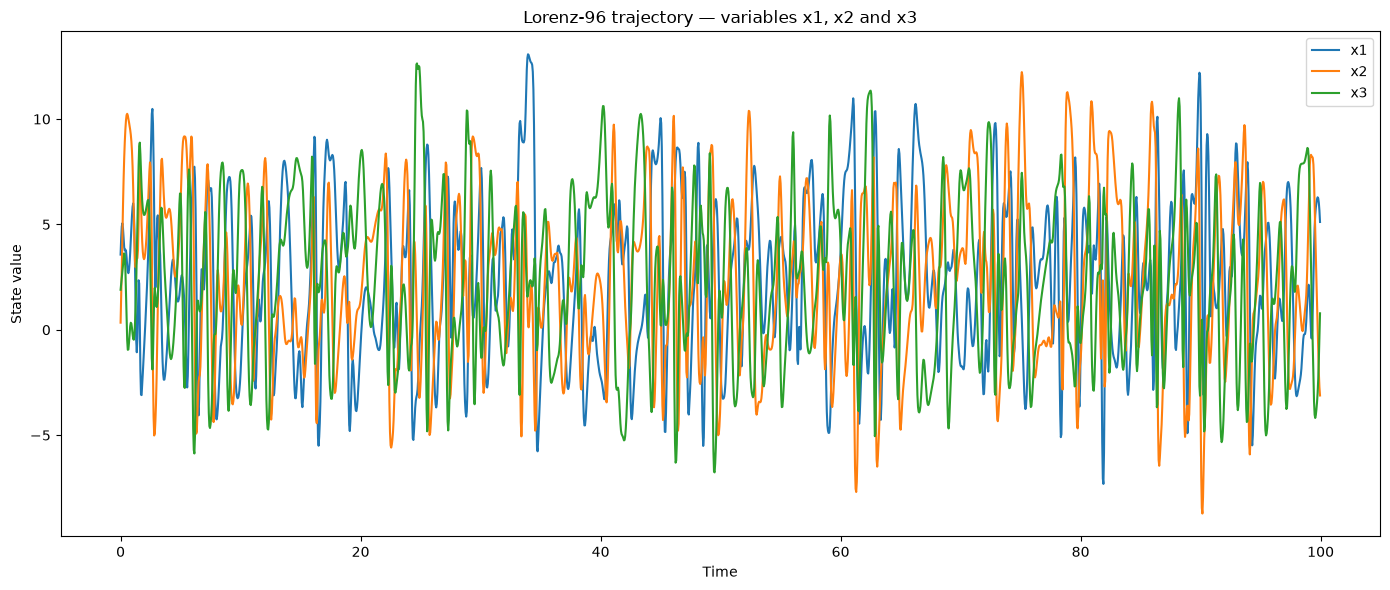

In [2]:
trajectory = train[0]

effective_dt = 0.05

time = np.arange(
    trajectory.shape[0]
) * effective_dt

plt.figure(figsize=(14, 6))

plt.plot(
    time,
    trajectory[:, 0],
    label="x1",
)

plt.plot(
    time,
    trajectory[:, 1],
    label="x2",
)

plt.plot(
    time,
    trajectory[:, 2],
    label="x3",
)

plt.xlabel("Time")
plt.ylabel("State value")
plt.title(
    "Lorenz-96 trajectory — variables x1, x2 and x3"
)

plt.legend()
plt.tight_layout()
plt.show()

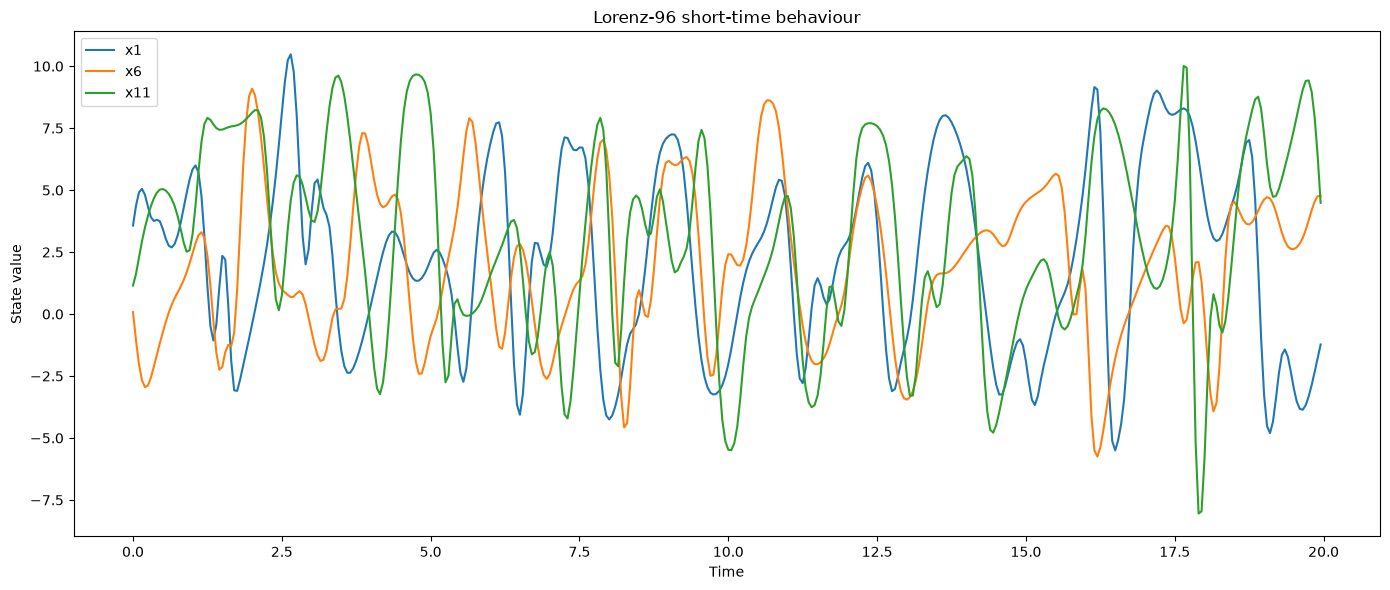

In [3]:
num_points = 400

plt.figure(figsize=(14, 6))

plt.plot(
    time[:num_points],
    trajectory[:num_points, 0],
    label="x1",
)

plt.plot(
    time[:num_points],
    trajectory[:num_points, 5],
    label="x6",
)

plt.plot(
    time[:num_points],
    trajectory[:num_points, 10],
    label="x11",
)

plt.xlabel("Time")
plt.ylabel("State value")
plt.title(
    "Lorenz-96 short-time behaviour"
)

plt.legend()
plt.tight_layout()
plt.show()

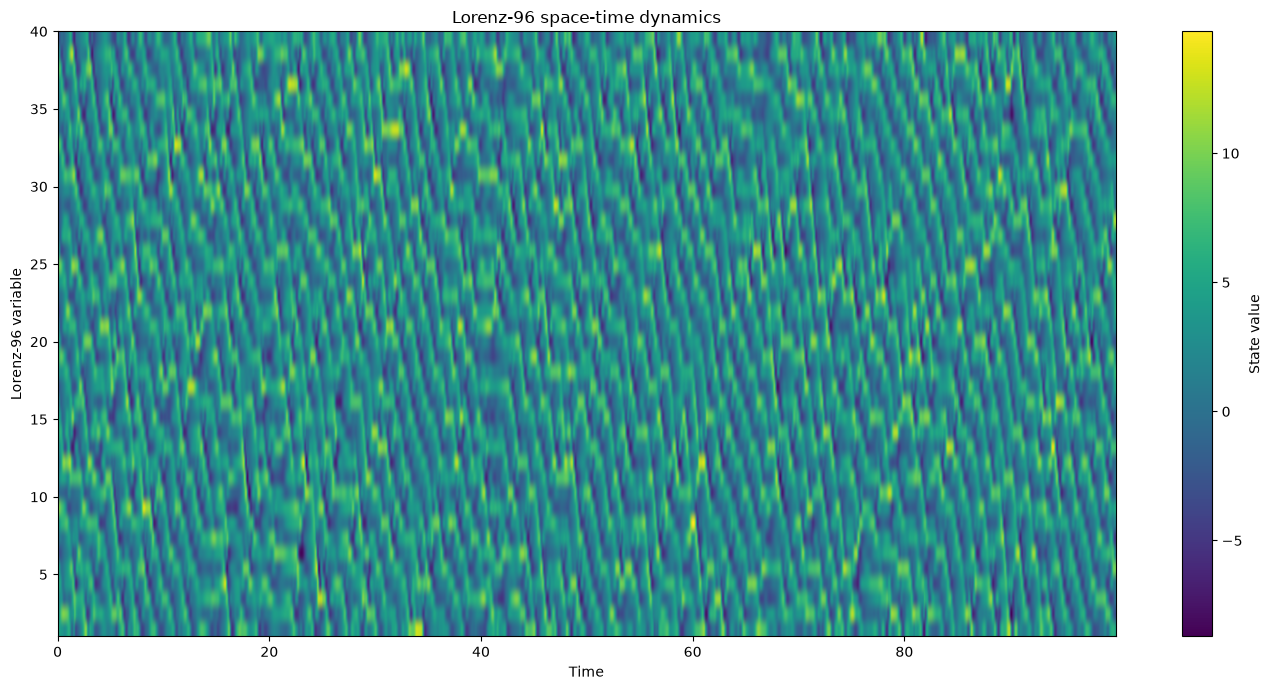

In [4]:
plt.figure(figsize=(14, 7))

plt.imshow(
    trajectory.T,
    aspect="auto",
    origin="lower",
    extent=[
        time[0],
        time[-1],
        1,
        trajectory.shape[1],
    ],
)

plt.colorbar(
    label="State value"
)

plt.xlabel("Time")
plt.ylabel("Lorenz-96 variable")
plt.title(
    "Lorenz-96 space-time dynamics"
)

plt.tight_layout()
plt.show()

In [5]:
variable_means = train.mean(
    axis=(0, 1)
)

variable_stds = train.std(
    axis=(0, 1)
)

for i in range(40):
    print(
        f"x{i+1:02d}: "
        f"mean={variable_means[i]:7.3f}, "
        f"std={variable_stds[i]:7.3f}"
    )

x01: mean=  2.353, std=  3.659
x02: mean=  2.296, std=  3.633
x03: mean=  2.361, std=  3.632
x04: mean=  2.387, std=  3.664
x05: mean=  2.322, std=  3.641
x06: mean=  2.346, std=  3.614
x07: mean=  2.378, std=  3.669
x08: mean=  2.294, std=  3.609
x09: mean=  2.357, std=  3.623
x10: mean=  2.383, std=  3.654
x11: mean=  2.312, std=  3.663
x12: mean=  2.301, std=  3.618
x13: mean=  2.397, std=  3.652
x14: mean=  2.335, std=  3.656
x15: mean=  2.280, std=  3.637
x16: mean=  2.377, std=  3.652
x17: mean=  2.376, std=  3.656
x18: mean=  2.311, std=  3.612
x19: mean=  2.330, std=  3.627
x20: mean=  2.377, std=  3.649
x21: mean=  2.333, std=  3.649
x22: mean=  2.336, std=  3.623
x23: mean=  2.358, std=  3.637
x24: mean=  2.348, std=  3.651
x25: mean=  2.333, std=  3.647
x26: mean=  2.327, std=  3.624
x27: mean=  2.341, std=  3.626
x28: mean=  2.342, std=  3.616
x29: mean=  2.334, std=  3.615
x30: mean=  2.298, std=  3.655
x31: mean=  2.329, std=  3.626
x32: mean=  2.351, std=  3.643
x33: mea

In [6]:
print(
    "Trajectory 0 vs trajectory 1 identical:",
    np.array_equal(
        train[0],
        train[1],
    )
)

print(
    "Maximum absolute difference:",
    np.max(
        np.abs(
            train[0] - train[1]
        )
    )
)

Trajectory 0 vs trajectory 1 identical: False
Maximum absolute difference: 19.79283


In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

from src.data.lorenz96 import generate_trajectory

In [9]:
a = generate_trajectory(
    num_saved_steps=100,
    seed=42,
)

b = generate_trajectory(
    num_saved_steps=100,
    seed=42,
)

print(
    "Same seed produces same trajectory:",
    np.array_equal(a, b),
)

Same seed produces same trajectory: True
